# 🛍️ Oasis Infobyte SIP — Data Analytics Track (Level 1)
## Task 2: Customer Segmentation Analysis
**Intern Name:** Rajesh  
**Domain:** Data Analytics  
**Task Title:** Level 1 - Task 2: Customer Segmentation Analysis  
**Repository:** `OIBSIP/DataAnalytics-L1-CustomerSegmentation/`  

---

### 🎯 Project Objectives & Checklist
This project applies unsupervised machine learning (K-Means Clustering) on an e-commerce transactional dataset using the RFM (Recency, Frequency, Monetary) behavioral framework. By segmenting the customer base into distinct cohorts, we formulate targeted marketing strategies to maximize Customer Lifetime Value (CLV) and reduce churn.

- [x] **Data Ingestion & Integrity Audit**: Inspect structure, handle missing `CustomerID` values, remove cancellations/returns.
- [x] **Descriptive Statistics**: Compute Average Purchase Value (AOV), Purchase Frequency, and Customer Lifetime Value (CLV).
- [x] **Feature Selection**: Engineer RFM features (Recency, Frequency, Monetary) from raw transactional logs.
- [x] **Data Normalization & Standardization**: Apply Log Transformation and `StandardScaler` to handle extreme right-skewness.
- [x] **K-Means Clustering**: Determine optimal clusters ($K$) using the Elbow Method (Inertia/WCSS) and Silhouette Score analysis.
- [x] **Cluster Visualizations**: Scatter plots across multiple feature dimensions (Recency vs. Monetary, Frequency vs. Monetary, Recency vs. Frequency).
- [x] **Cluster Profiling**: Quantify mean and median RFM metrics per cluster and assign distinct customer personas.
- [x] **Bar Charts**: Visualize customer distribution and aggregate revenue contribution share per cluster.
- [x] **Targeted Marketing Strategies**: Formulate high-impact, actionable business recommendations for each customer segment.


---
## 1. Environment Setup & Library Imports
Import foundational packages for data manipulation (`pandas`, `numpy`), visual analytics (`matplotlib`, `seaborn`), and machine learning clustering (`scikit-learn`).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("✅ Analytics & Machine Learning environment initialized successfully!")

✅ Analytics & Machine Learning environment initialized successfully!


---
## 2. Data Ingestion & Data Quality Cleaning
We load the raw transactional dataset, audit for missing customer identifiers (guest checkouts), filter out negative return/cancellation quantities, and format dates and pricing.

In [ ]:
df_raw = pd.read_csv("data/ecommerce_transactions.csv")
print(f"Raw Transactional Records: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Missing Customer IDs: {df_raw['CustomerID'].isnull().sum():,} ({df_raw['CustomerID'].isnull().mean():.2%})")

# 1. Filter out guest checkouts (unregistered transactions cannot be attributed to customer entities)
df_clean = df_raw.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 2. Filter out cancellations and return transactions
is_cancelled = df_clean['InvoiceNo'].astype(str).str.startswith('C') | (df_clean['Quantity'] <= 0)
df_clean = df_clean[~is_cancelled].copy()

# 3. Clean product descriptions and parse dates
df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['LineTotal'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Cleaned Valid Transactions: {len(df_clean):,}")
print(f"Unique Customers: {df_clean['CustomerID'].nunique():,}")
print(f"Date Range: {df_clean['InvoiceDate'].min().strftime('%Y-%m-%d')} to {df_clean['InvoiceDate'].max().strftime('%Y-%m-%d')}")
df_clean.head()

Raw Transactional Records: 26,340
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Missing Customer IDs: 658 (2.50%)
Cleaned Valid Transactions: 25,518
Unique Customers: 848
Date Range: 2023-01-06 to 2024-12-30


---
## 3. RFM Feature Engineering & Descriptive Statistics
We calculate:
- **Recency ($R$)**: Days since the customer's last recorded purchase relative to the snapshot date.
- **Frequency ($F$)**: Total number of unique orders/invoices placed by the customer.
- **Monetary ($M$)**: Total revenue generated by the customer (Customer Lifetime Value).
- **Average Purchase Value (AOV)**: Monetary / Frequency.

In [ ]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'LineTotal': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'LineTotal': 'Monetary'
}, inplace=True)

rfm['AveragePurchaseValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['CustomerLifetimeValue'] = rfm['Monetary']

desc_stats = rfm[['Recency', 'Frequency', 'Monetary', 'AveragePurchaseValue', 'CustomerLifetimeValue']].describe().T
desc_stats['median'] = rfm[['Recency', 'Frequency', 'Monetary', 'AveragePurchaseValue', 'CustomerLifetimeValue']].median()
desc_stats['skewness'] = rfm[['Recency', 'Frequency', 'Monetary', 'AveragePurchaseValue', 'CustomerLifetimeValue']].skew()

desc_stats[['mean', 'median', 'std', 'min', 'max', 'skewness']]

                            mean      median          std   min           max  skewness
Recency               147.650943   49.500000   178.854616  1.00    719.000000  1.267062
Frequency               6.101415    5.000000     4.748613  1.00     21.000000  1.337629
Monetary             1720.678078  707.880000  2724.339230  0.83  13352.360000  2.026396
AveragePurchaseValue  171.996229  125.025833   162.649375  0.83    669.378947  1.330761
CustomerLifetimeValue 1720.678078 707.880000  2724.339230  0.83  13352.360000  2.026396


---
## 4. Feature Preprocessing & Standardization
K-Means clustering uses Euclidean distance, making it sensitive to scale and extreme right-skewness. We apply a **Logarithmic Transformation** (`log1p`) followed by `StandardScaler` to achieve zero mean and unit variance.

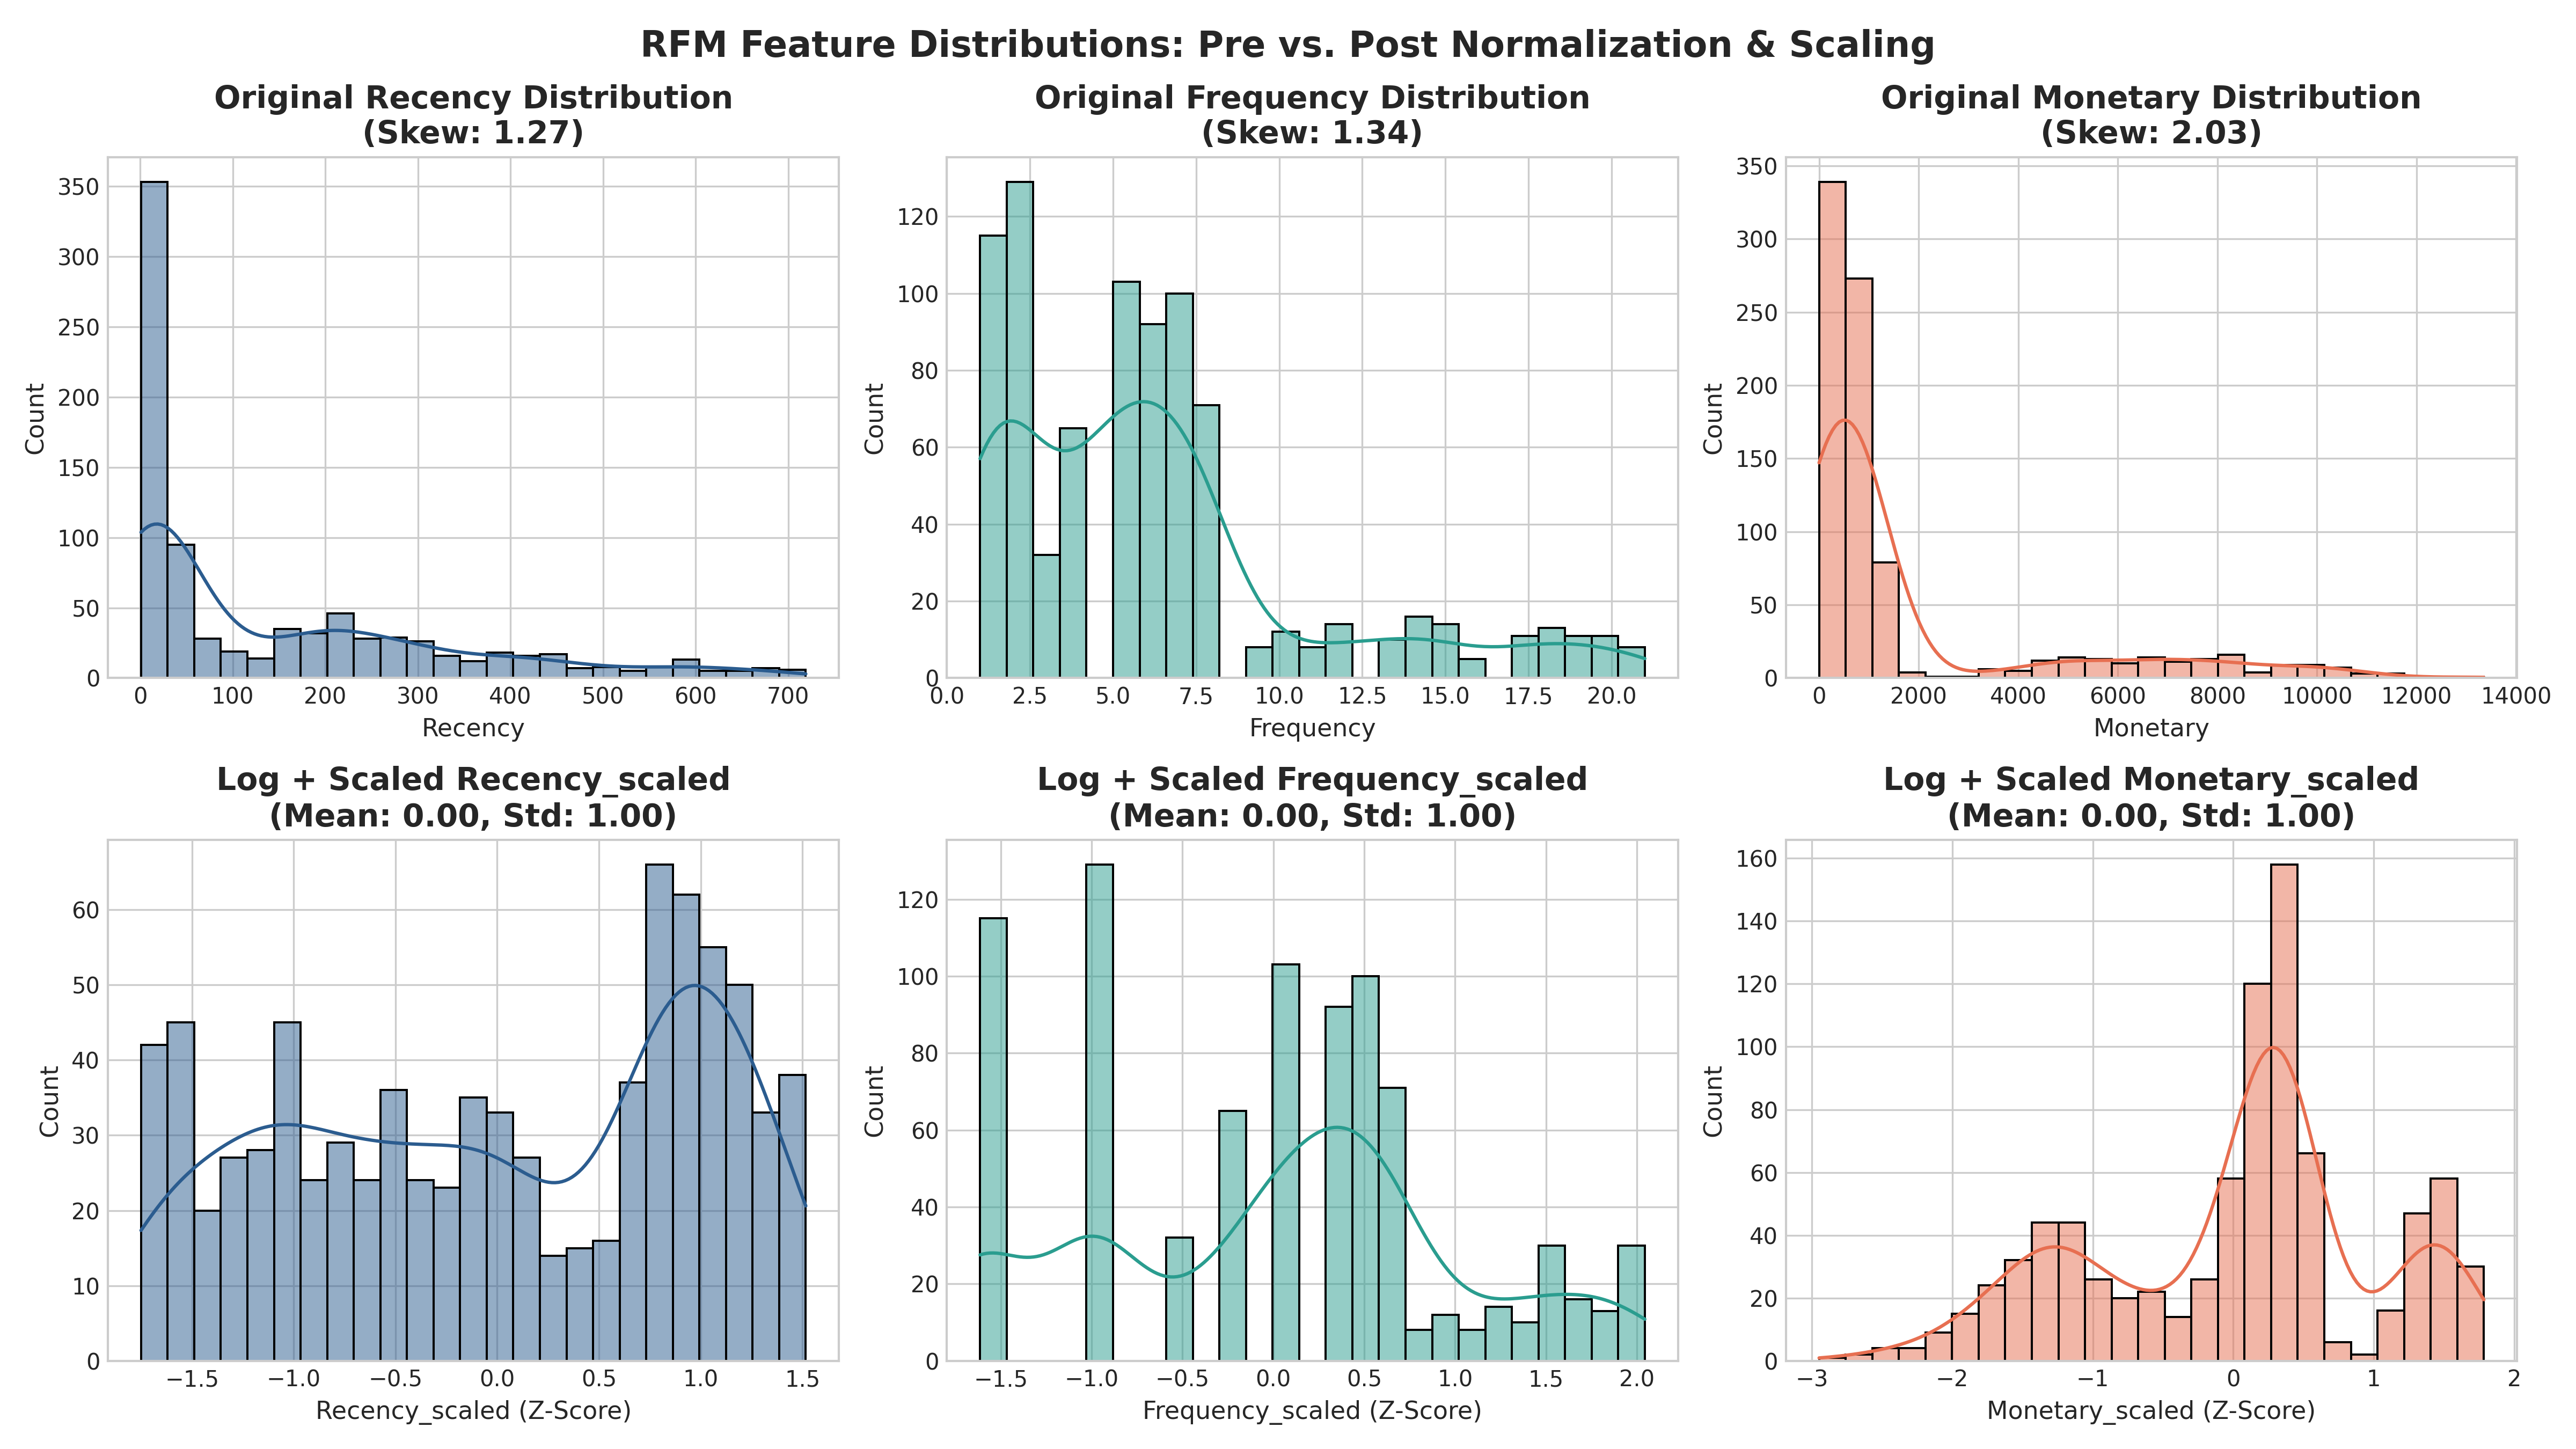

In [ ]:
rfm_log = pd.DataFrame()
rfm_log['CustomerID'] = rfm['CustomerID']
rfm_log['Recency_log'] = np.log1p(rfm['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm['Monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

# Visualization of distributions
from IPython.display import Image, display
display(Image(filename="visualizations/02_rfm_distributions_before_after_scaling.png"))

---
## 5. K-Means Clustering: Elbow Method & Silhouette Score
We evaluate candidate cluster counts from $K=2$ to $K=10$ to find the optimal balance between within-cluster cohesion and between-cluster separation.

K =  2 | WCSS (Inertia):  1036.00 | Silhouette Score: 0.4859
K =  3 | WCSS (Inertia):   560.87 | Silhouette Score: 0.4758
K =  4 | WCSS (Inertia):   345.98 | Silhouette Score: 0.5125
K =  5 | WCSS (Inertia):   286.34 | Silhouette Score: 0.4737
K =  6 | WCSS (Inertia):   235.48 | Silhouette Score: 0.4380
K =  7 | WCSS (Inertia):   206.45 | Silhouette Score: 0.4233
K =  8 | WCSS (Inertia):   185.51 | Silhouette Score: 0.4037
K =  9 | WCSS (Inertia):   166.99 | Silhouette Score: 0.3737
K = 10 | WCSS (Inertia):   153.73 | Silhouette Score: 0.3579


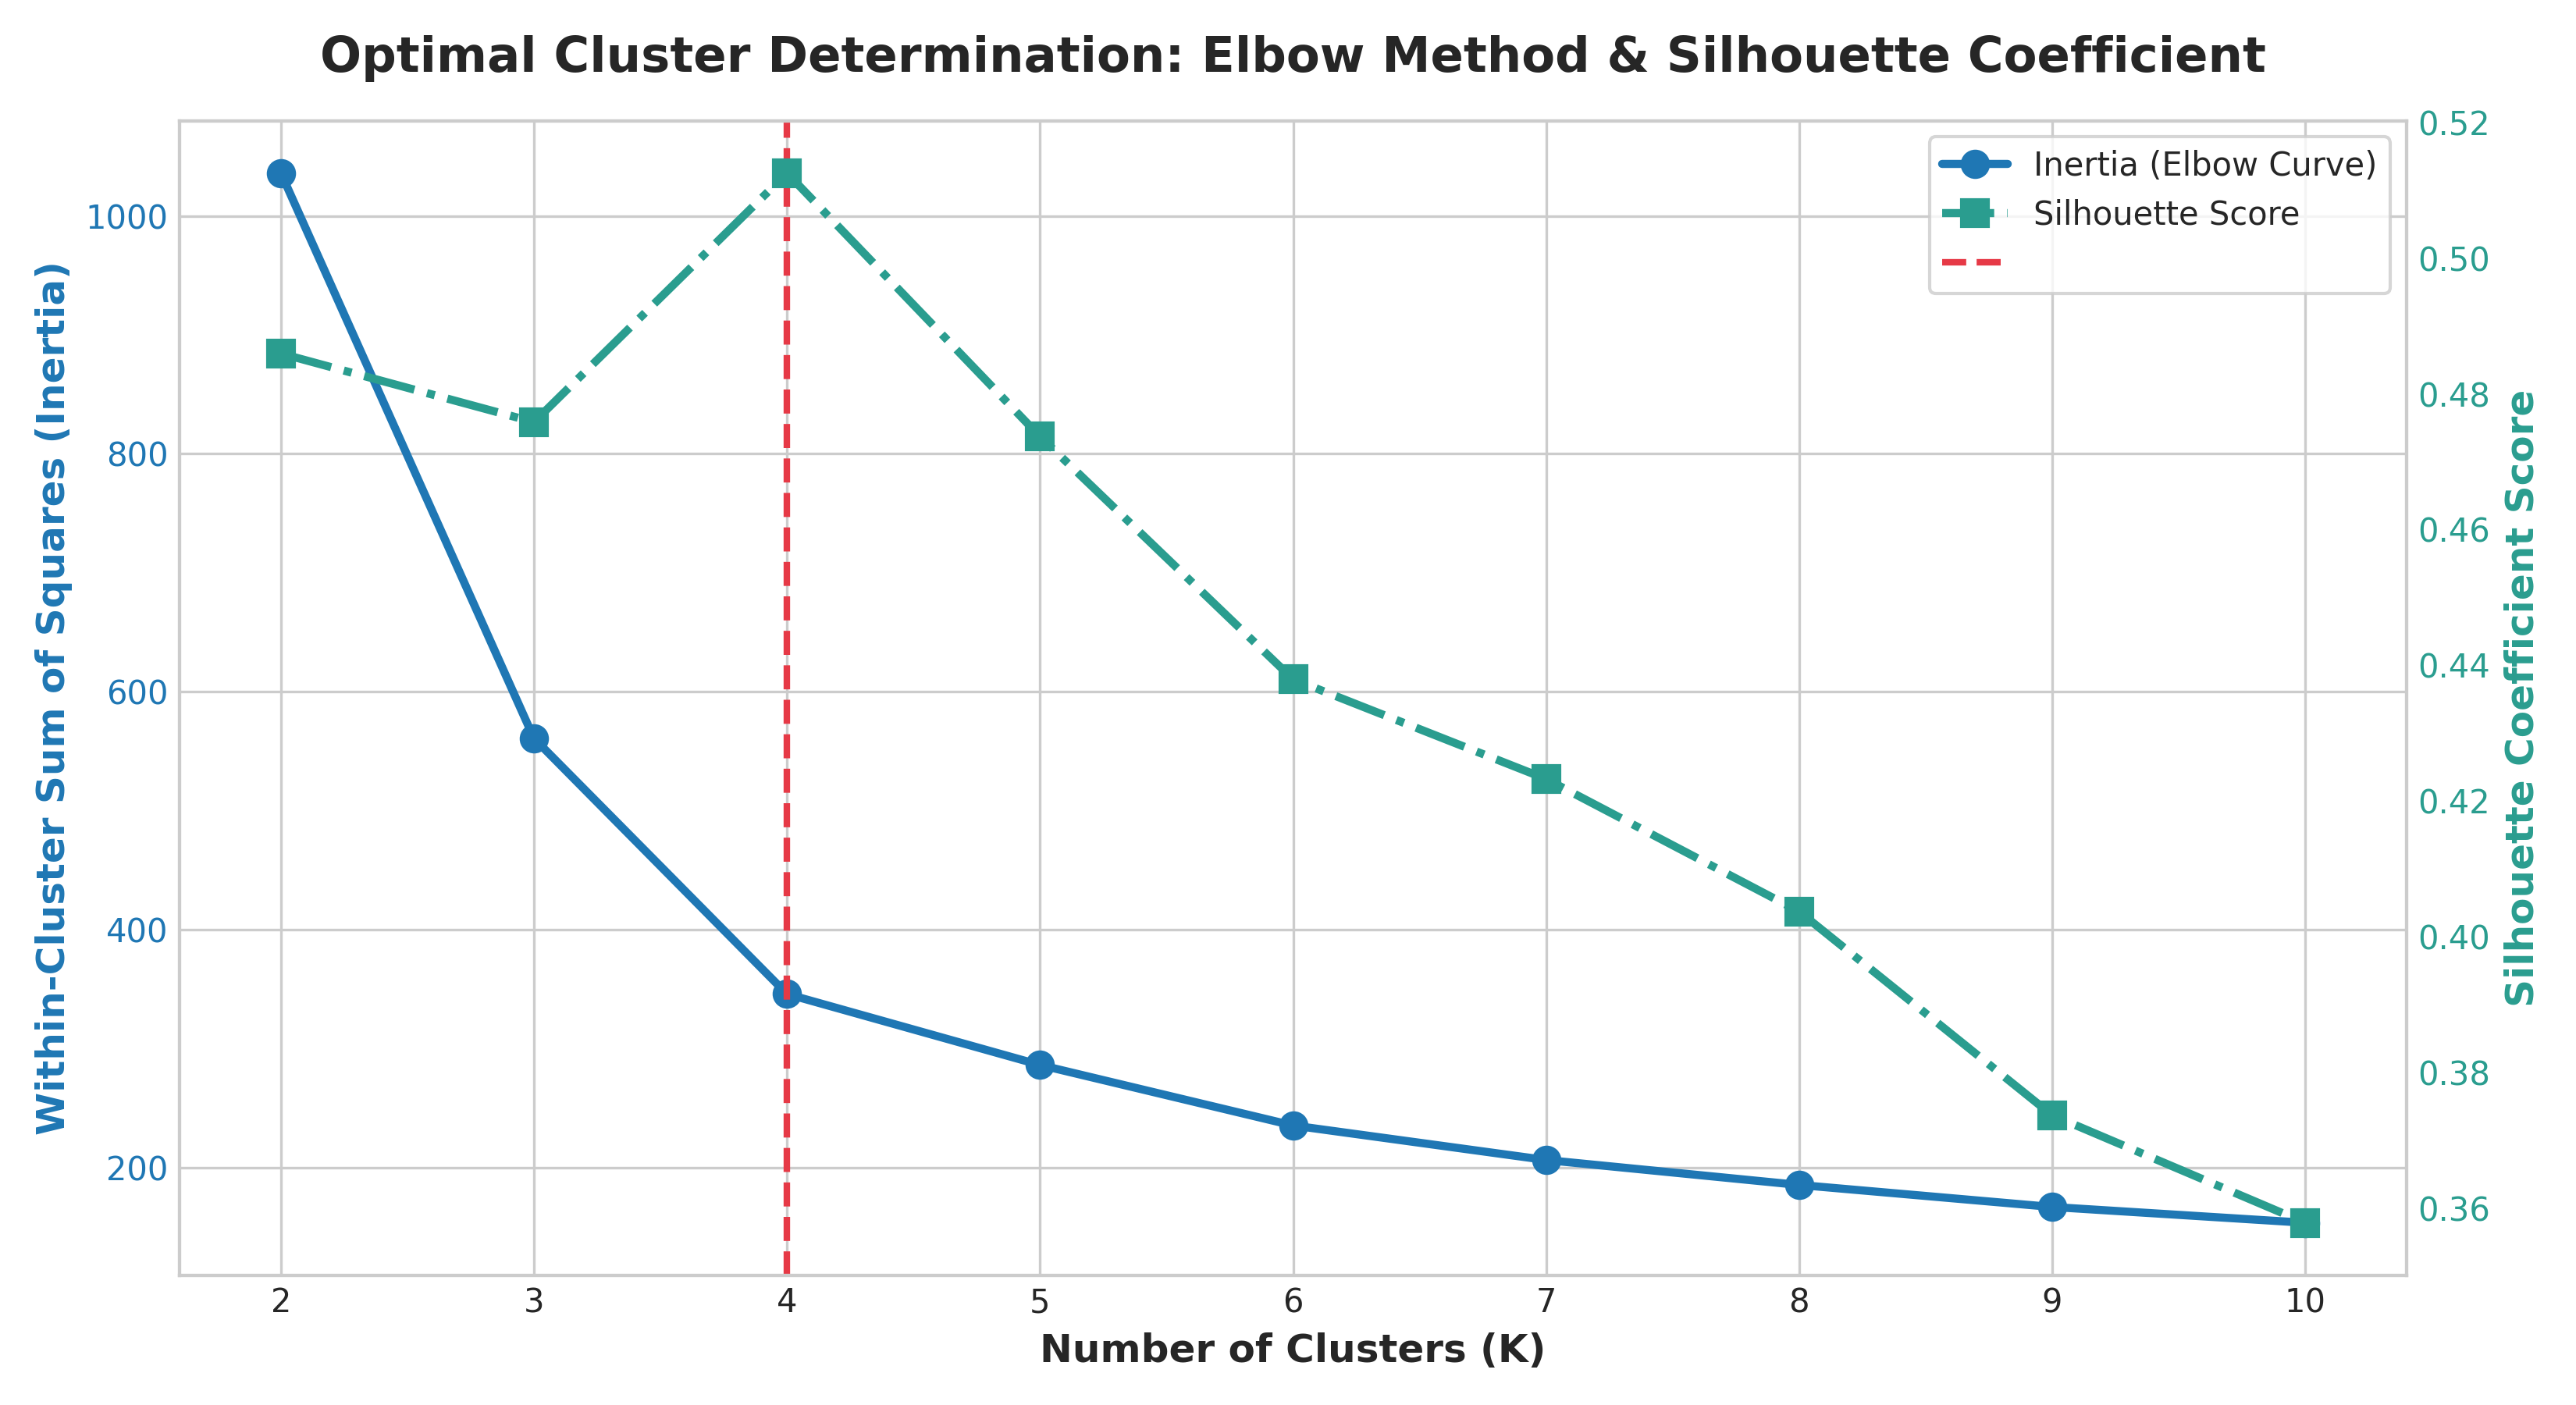

In [ ]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)
    score = silhouette_score(rfm_scaled, km.labels_)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | WCSS (Inertia): {km.inertia_:8.2f} | Silhouette Score: {score:.4f}")

display(Image(filename="visualizations/01_elbow_and_silhouette_analysis.png"))

---
## 6. Fitting Final K-Means ($K=4$) & Customer Profiling
Mathematical justification: $K=4$ delivers both an evident elbow inflection and the highest Silhouette Score (**0.5125**). We fit the model and assign quantitative personas.

In [ ]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', n_init=20, random_state=42)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Segment Persona Mapping based on empirical RFM values
persona_map = {
    3: "Champions (High-Value VIPs)",
    1: "Loyal Steady Shoppers",
    0: "At-Risk / Lapsed Spenders",
    2: "Occasional / Low-Engagement Shoppers"
}
rfm['Segment'] = rfm['Cluster'].map(persona_map)

# Detailed Profiles
profiles = rfm.groupby(['Cluster', 'Segment']).agg(
    Customer_Count=('CustomerID', 'count'),
    Avg_Recency_Days=('Recency', 'mean'),
    Median_Recency_Days=('Recency', 'median'),
    Avg_Frequency=('Frequency', 'mean'),
    Median_Frequency=('Frequency', 'median'),
    Avg_Monetary_Spend=('Monetary', 'mean'),
    Total_Segment_Revenue=('Monetary', 'sum')
).reset_index()

profiles['Pct_Customers'] = (profiles['Customer_Count'] / len(rfm)) * 100
profiles['Pct_Revenue'] = (profiles['Total_Segment_Revenue'] / rfm['Monetary'].sum()) * 100

profiles[['Segment', 'Customer_Count', 'Pct_Customers', 'Avg_Recency_Days', 'Avg_Frequency', 'Avg_Monetary_Spend', 'Pct_Revenue']]

                                Segment  Customer_Count  Pct_Customers  Avg_Recency_Days  Avg_Frequency  Avg_Monetary_Spend  Pct_Revenue
0             At-Risk / Lapsed Spenders             188      22.169811        251.882979       5.005319          622.146968     8.015957
1                 Loyal Steady Shoppers             274      32.311321         20.613139       6.273723          974.828285    18.305568
2  Occasional / Low-Engagement Shoppers             240      28.301887        298.495833       1.520833           50.791250     0.835420
3           Champions (High-Value VIPs)             146      17.216981          3.883562      14.719178         7279.989932    72.843056


---
## 7. Multi-Dimensional Cluster Visualizations
Examining customer clusters across key behavioral dimensions:
1. **Recency vs. Monetary Spend**
2. **Frequency vs. Monetary Spend**
3. **Recency vs. Purchase Frequency**

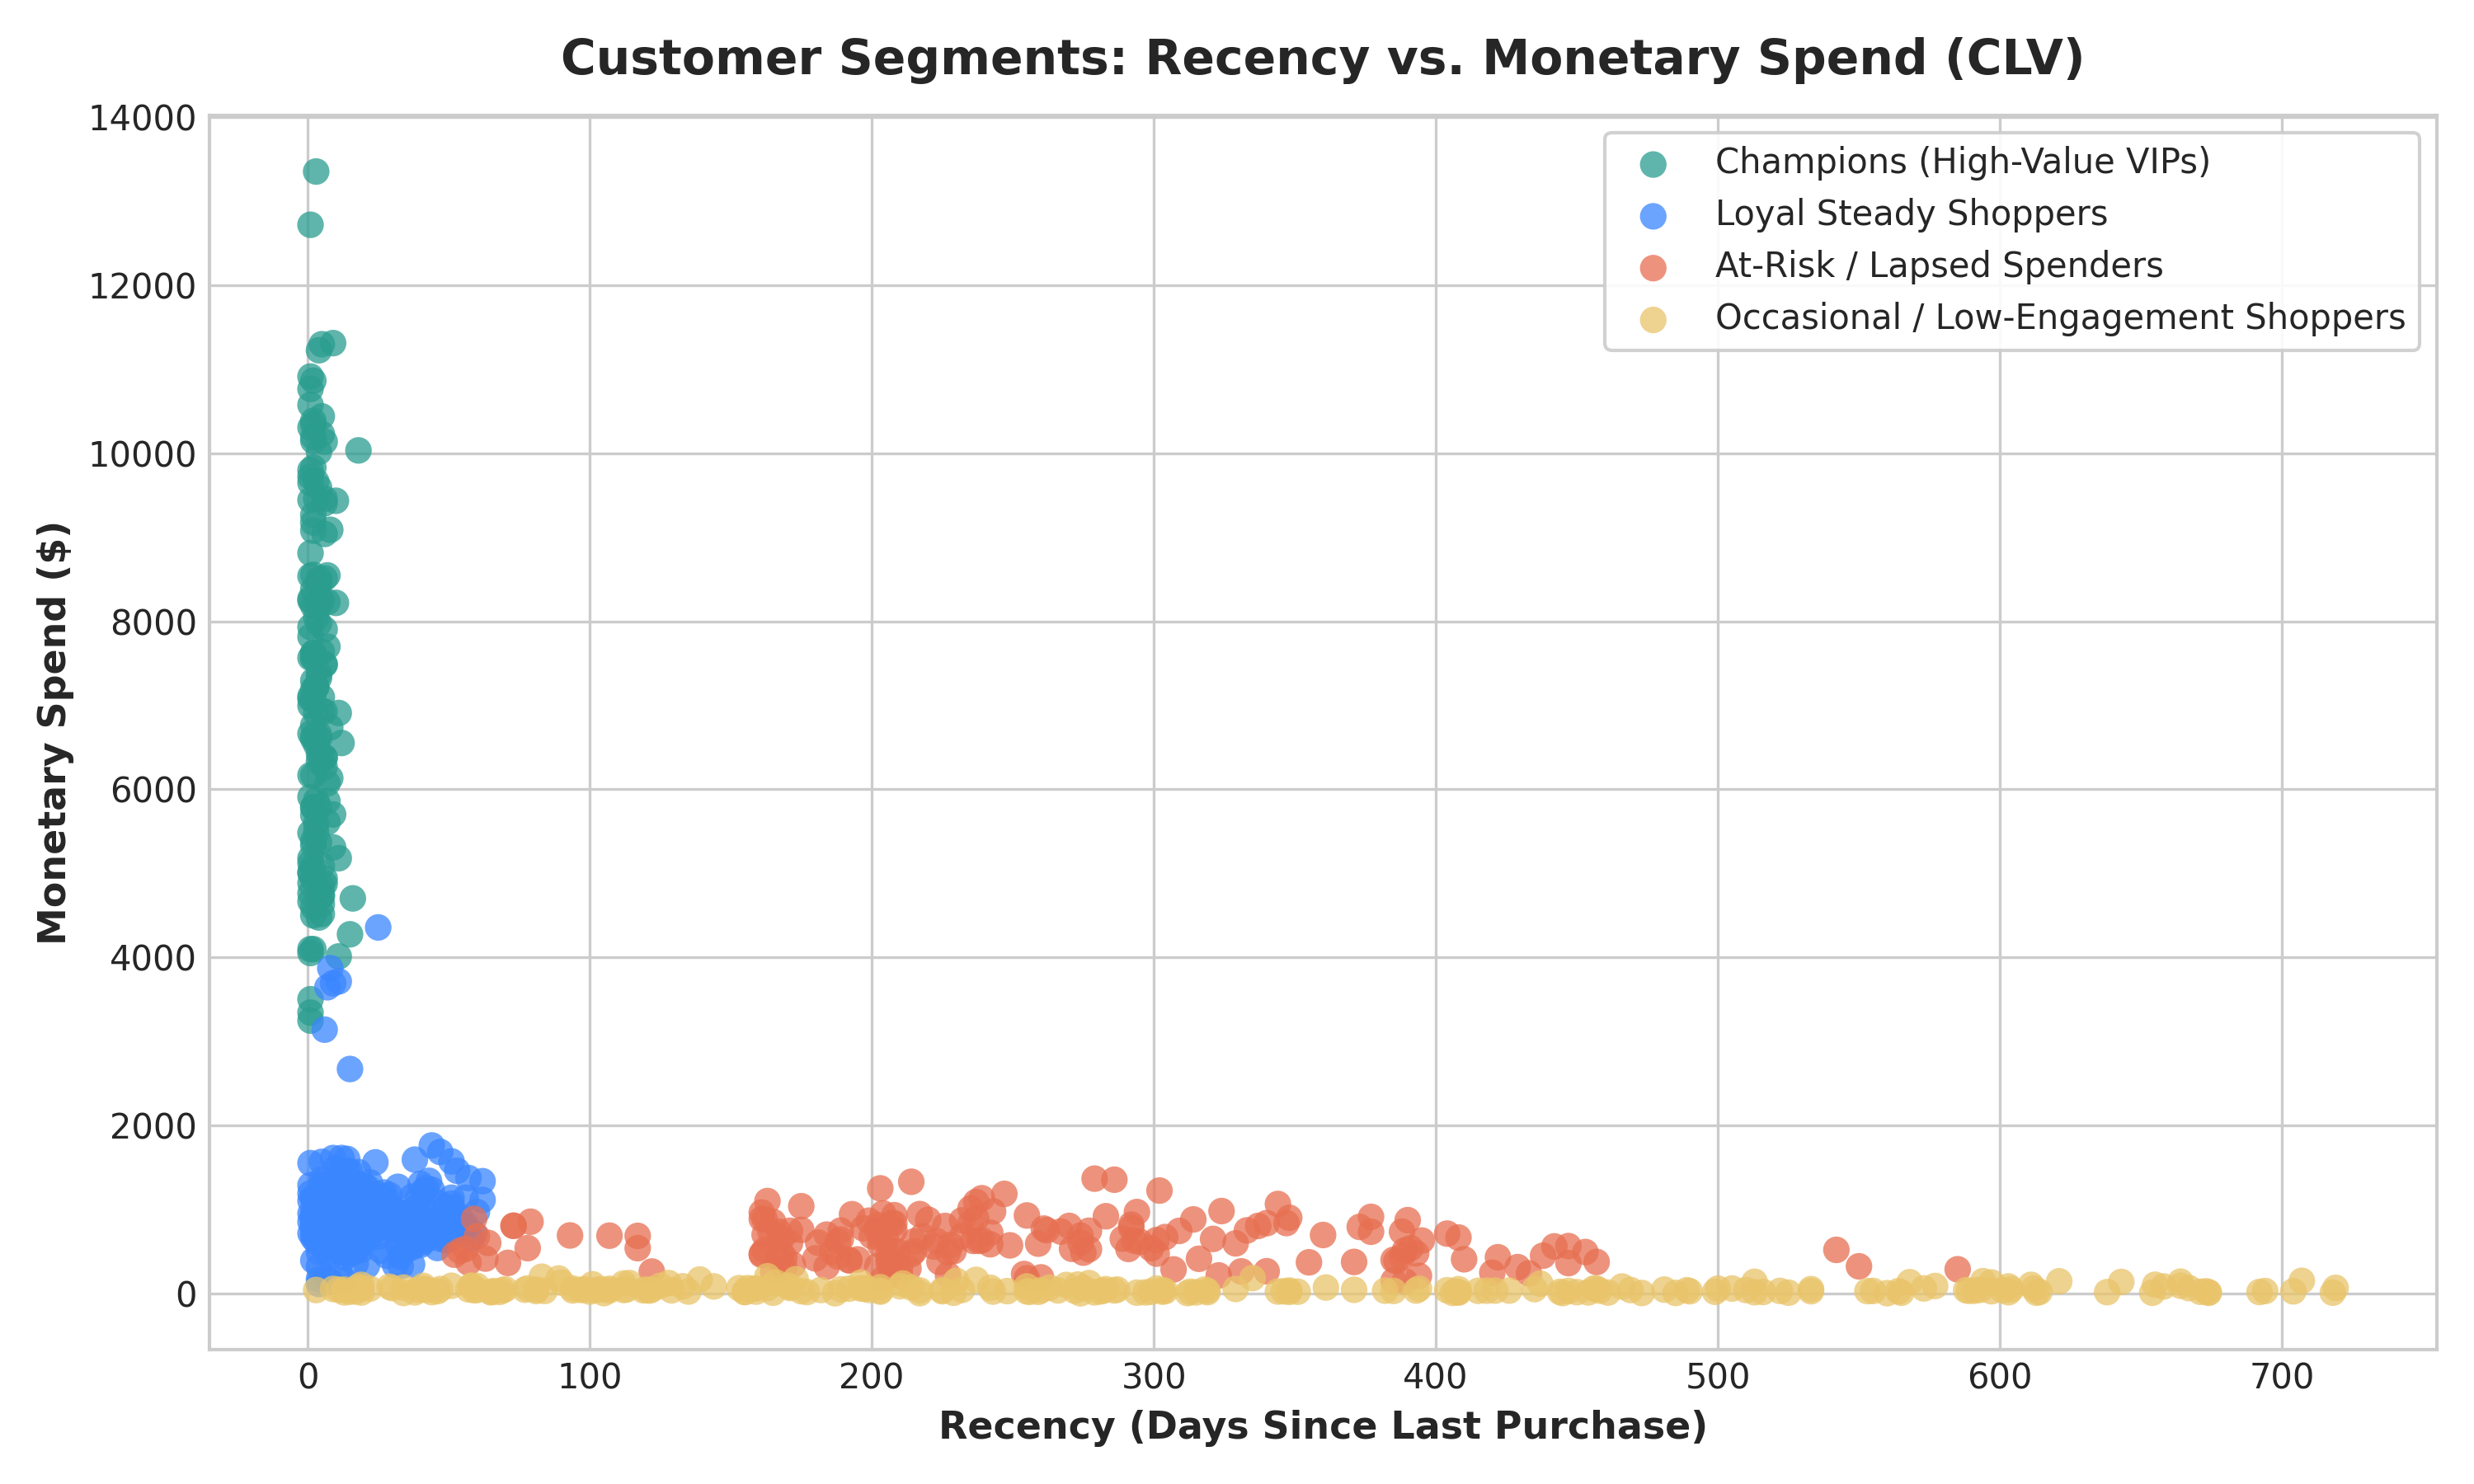

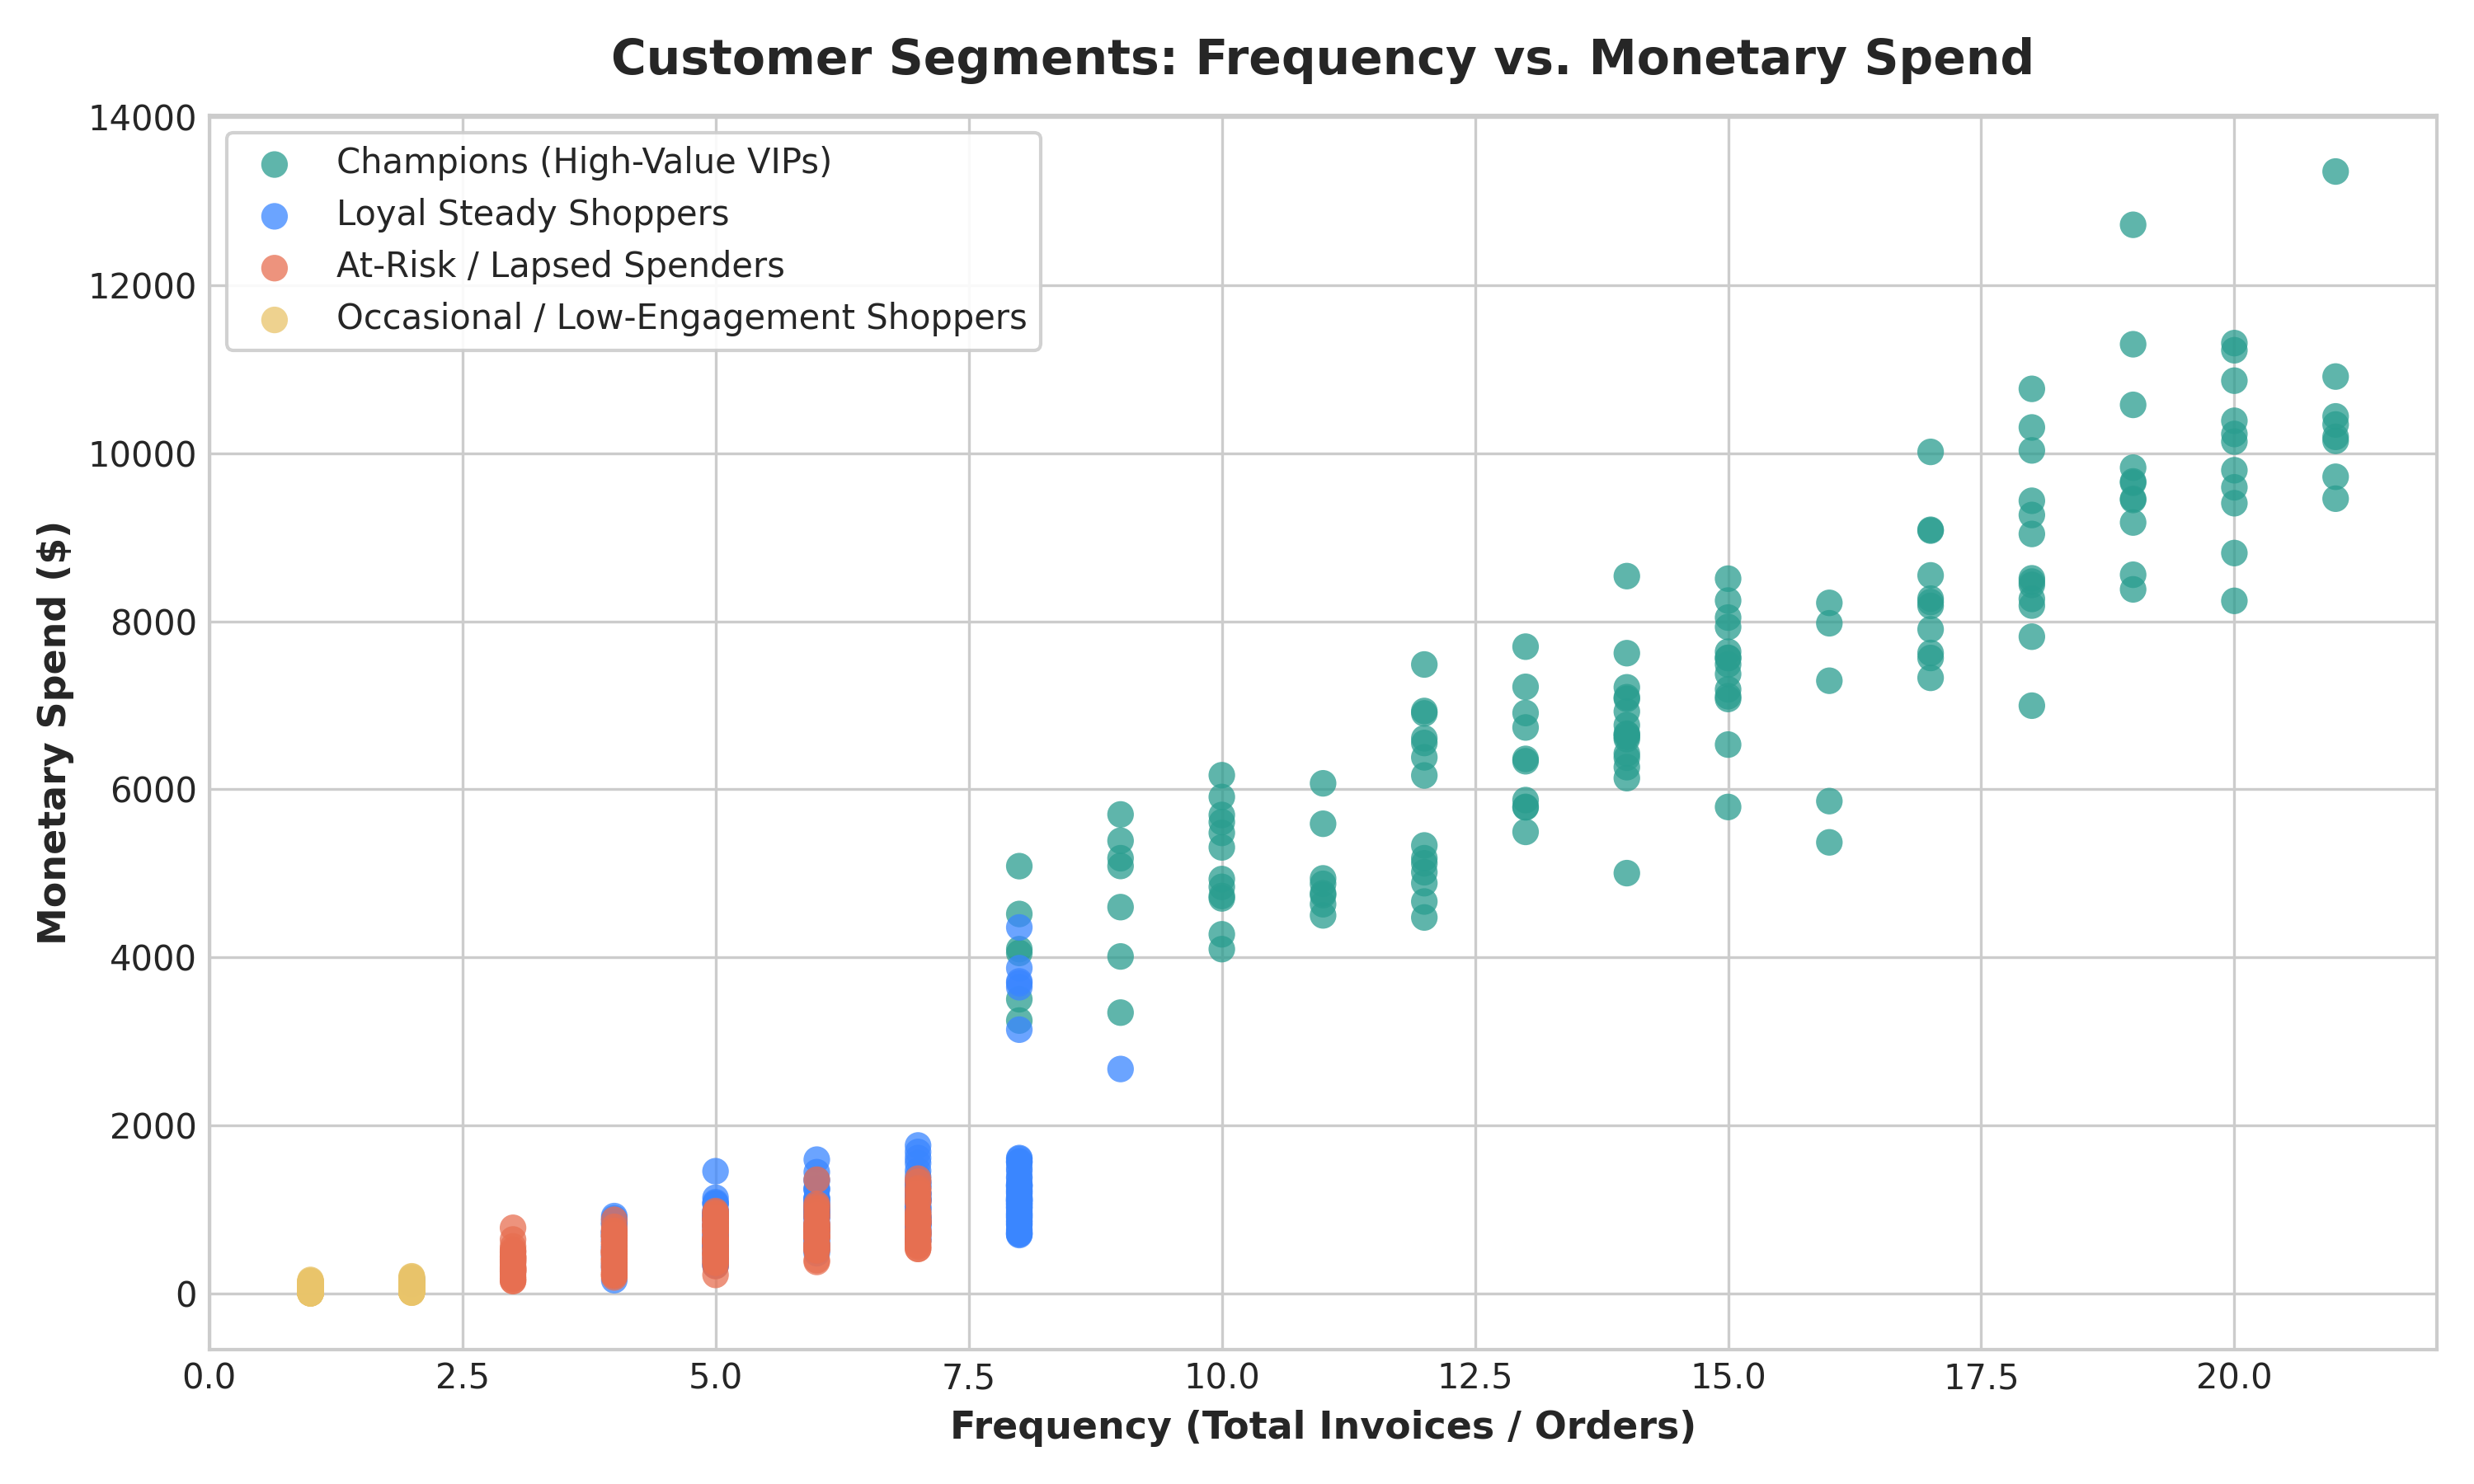

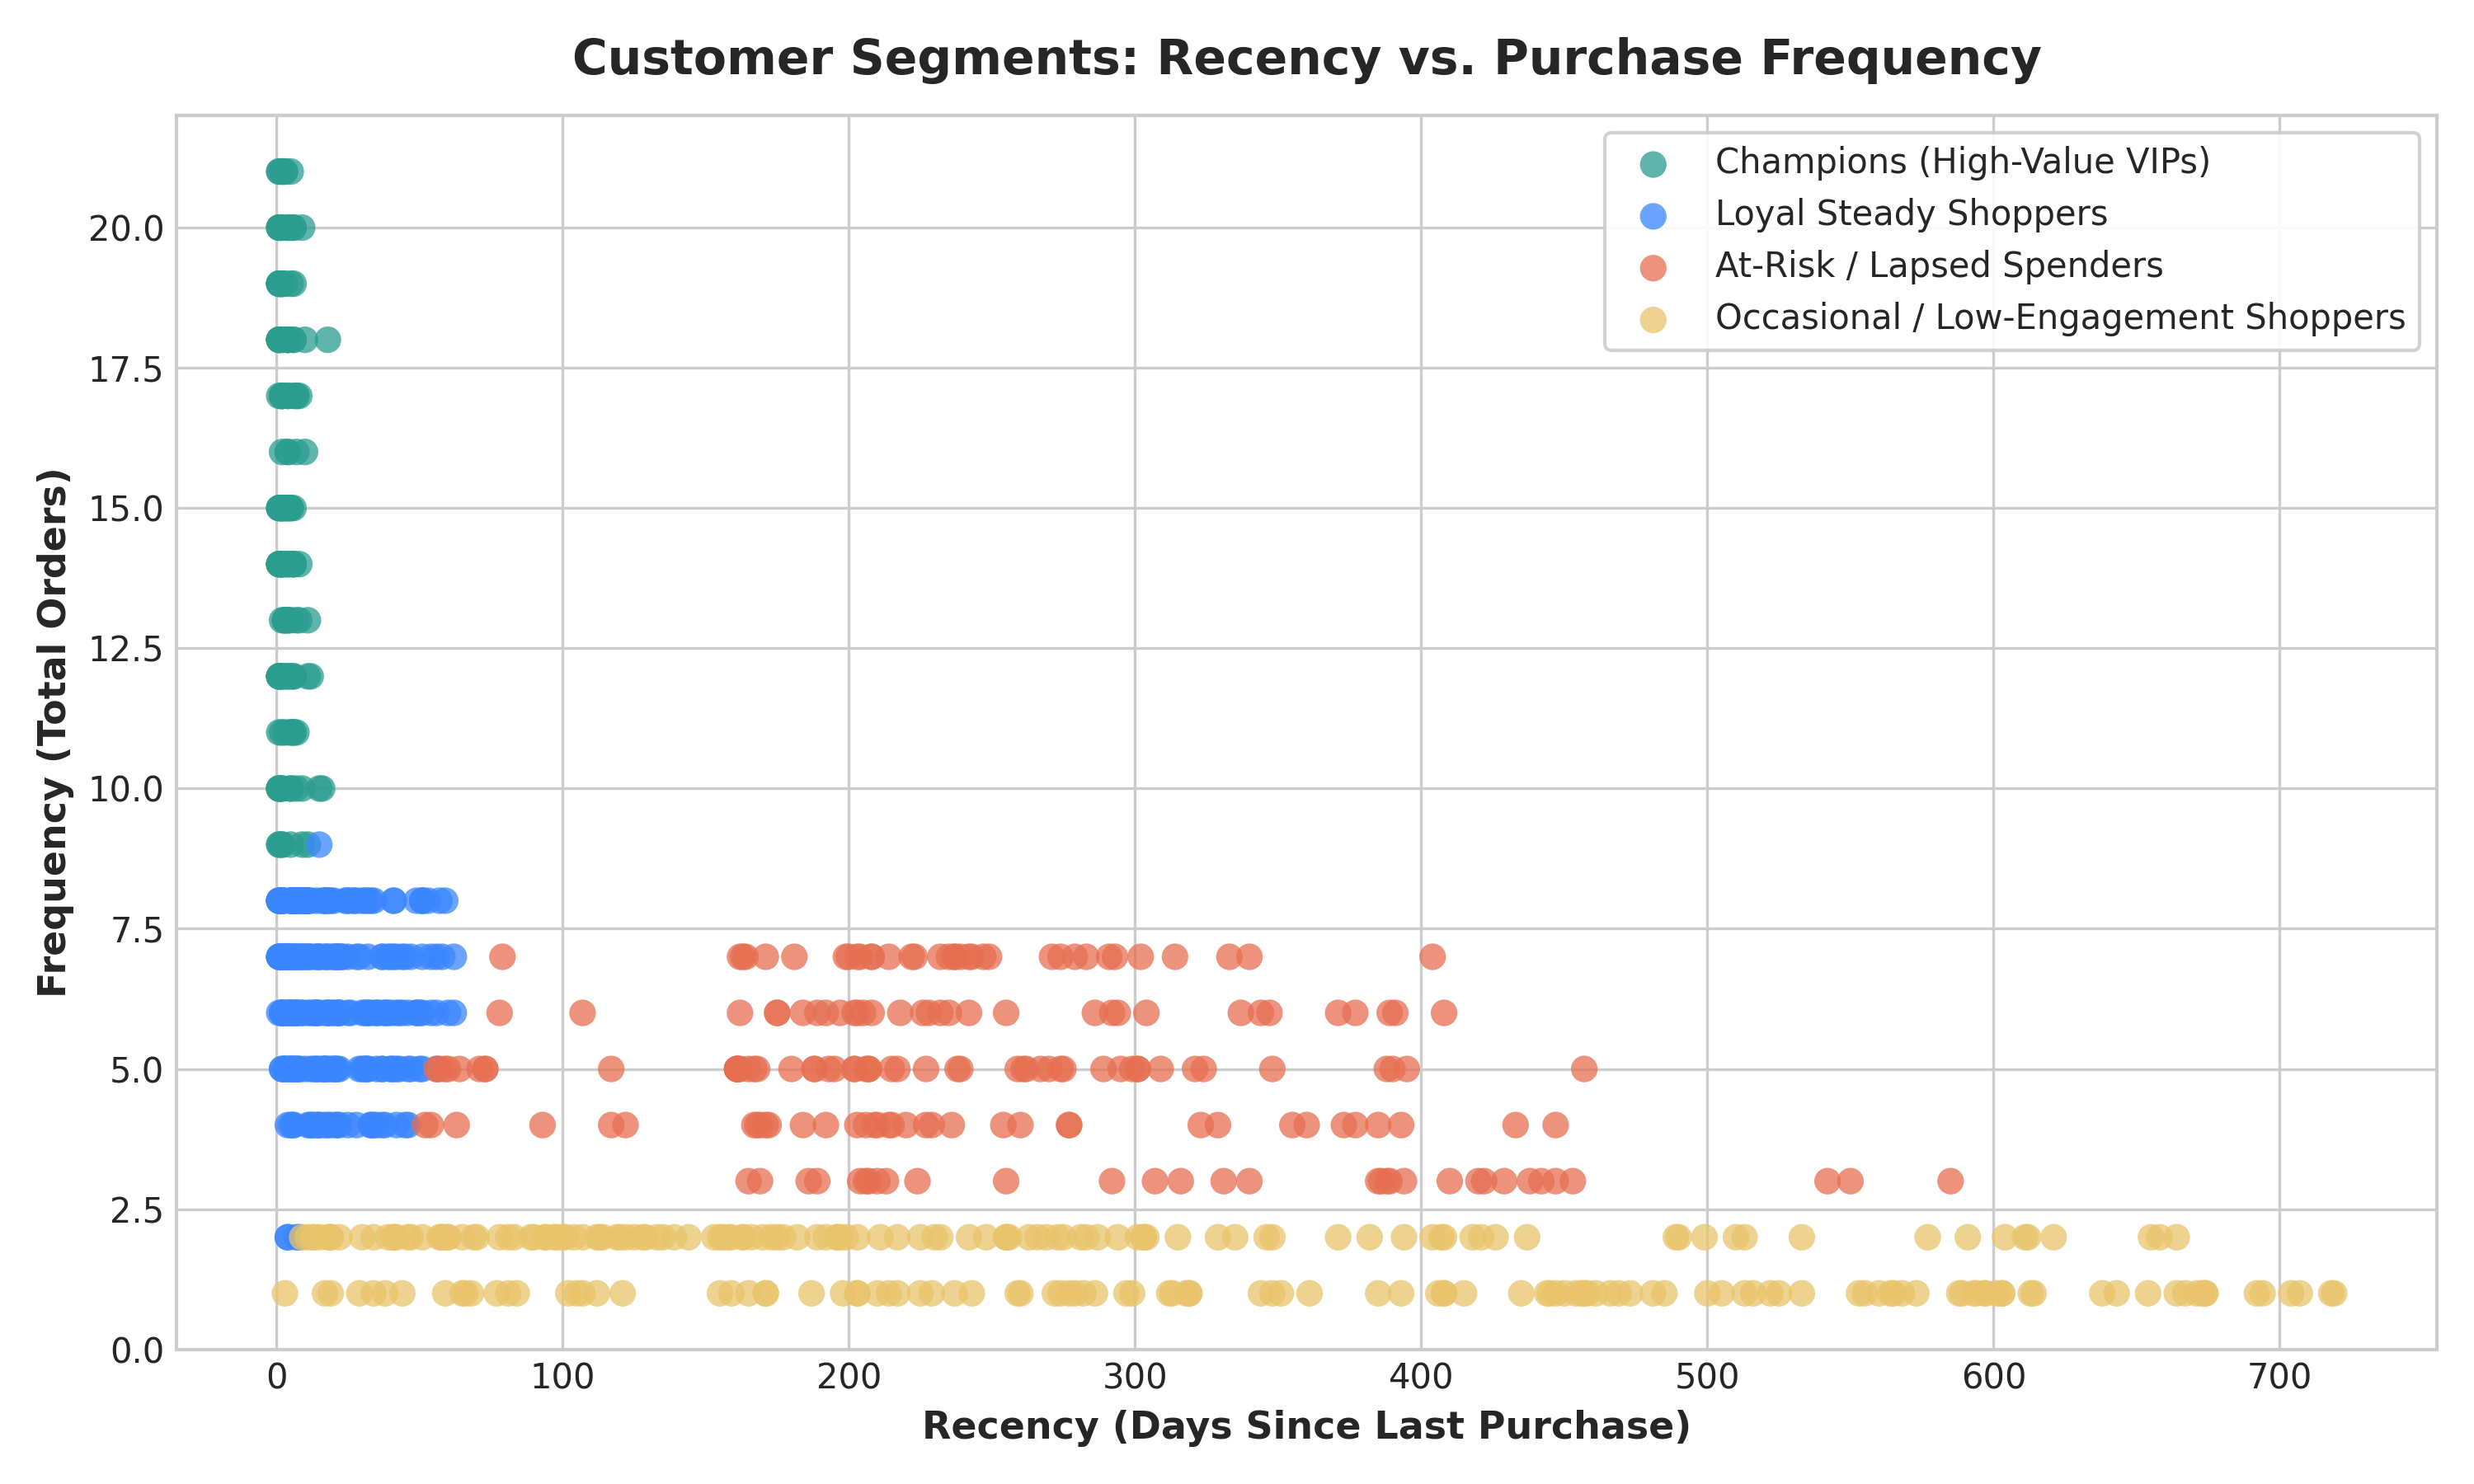

In [ ]:
display(Image(filename="visualizations/03_cluster_scatter_recency_monetary.png"))
display(Image(filename="visualizations/04_cluster_scatter_frequency_monetary.png"))
display(Image(filename="visualizations/05_cluster_scatter_recency_frequency.png"))

---
## 8. Customer Distribution & Behavioral Comparison Bar Charts
Comparing segment size vs. aggregate commercial revenue share, and average RFM metrics across each cluster.

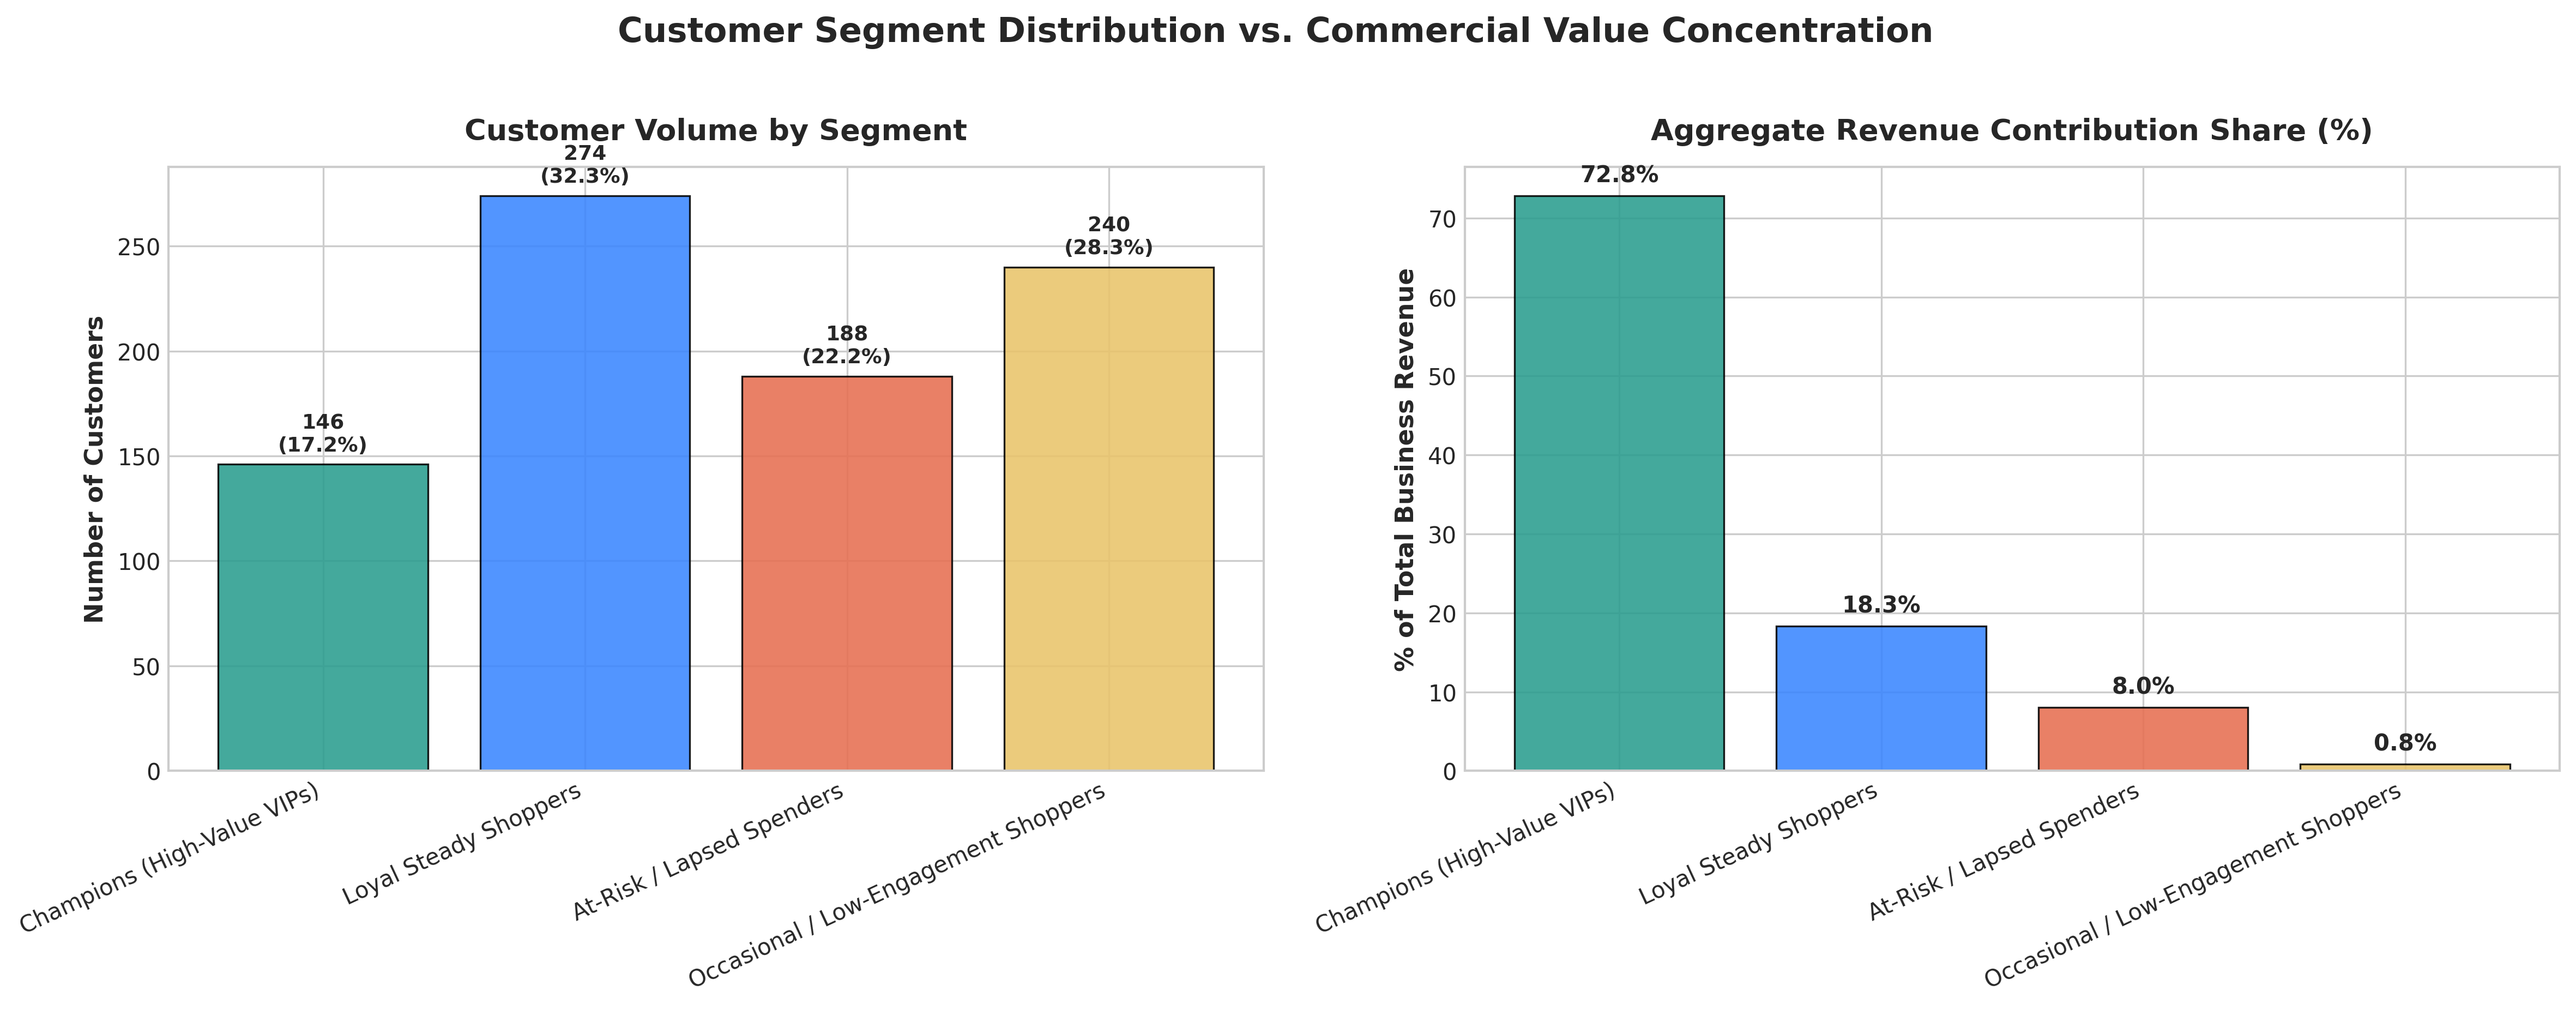

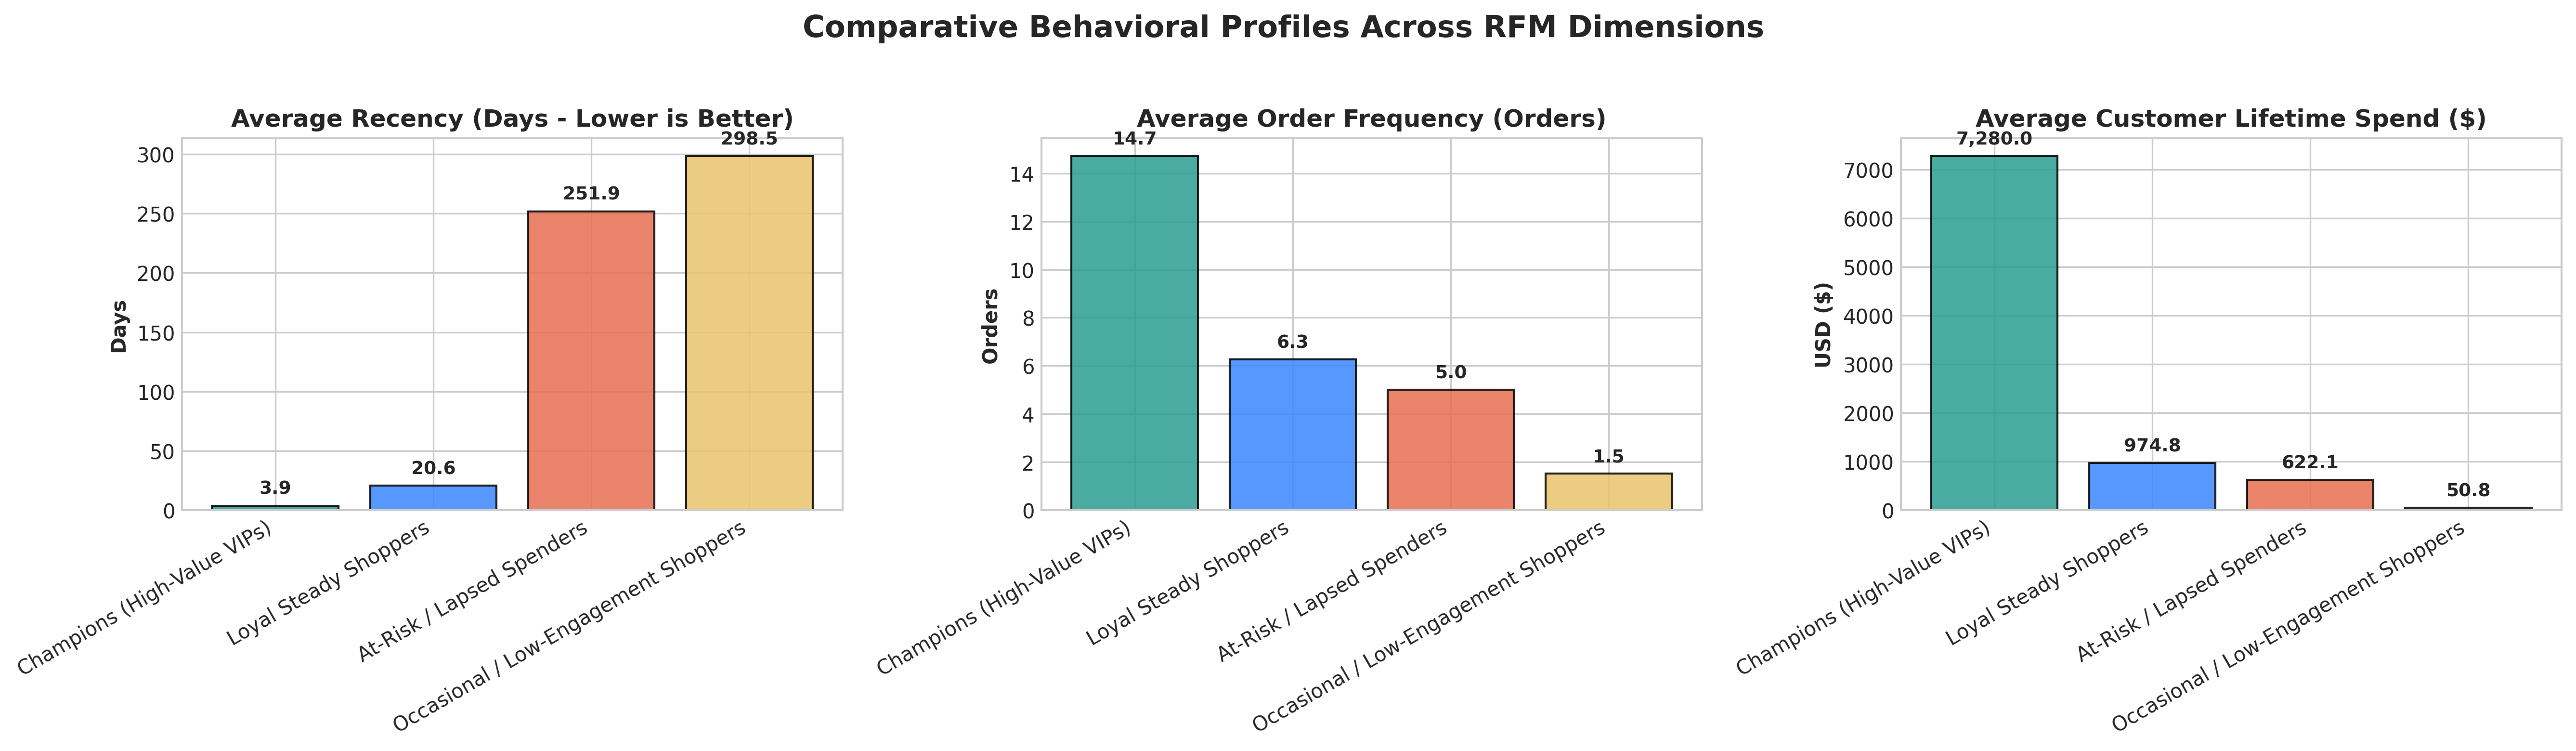

In [ ]:
display(Image(filename="visualizations/06_customer_distribution_per_cluster.png"))
display(Image(filename="visualizations/07_cluster_profiles_rfm_comparison.png"))

---
## 9. Executive Insights & Targeted Marketing Playbook

### 💎 Segment 1: Champions (High-Value VIPs) — 17.2% of Customers | 72.8% of Total Revenue
- **Profile:** Average Recency: 3.9 days | Average Frequency: 14.7 orders | Average Spend: $7,279.99.
- **Strategic Action:**
  - **VIP Concierge Service:** Dedicated premium customer support and priority dispatch.
  - **Early Access Exclusives:** 48-hour pre-launch windows for new product collections.
  - **Zero Discount Margin Dilution:** Avoid blanket percentage discount codes; reward with experiential perks, branded gifts, and tier-based loyalty multipliers.

### 🌟 Segment 2: Loyal Steady Shoppers — 32.3% of Customers | 18.3% of Total Revenue
- **Profile:** Average Recency: 20.6 days | Average Frequency: 6.3 orders | Average Spend: $974.83.
- **Strategic Action:**
  - **Basket Size Expansion:** Implement conditional threshold promotions (e.g., *"Spend $75 to unlock free expedited shipping and a curated bonus sample"*).
  - **Collaborative Recommendation Engine:** Deliver personalized cross-sell suggestions based on past category affinities.

### ⚠️ Segment 3: At-Risk / Lapsed Spenders — 22.2% of Customers | 8.0% of Total Revenue
- **Profile:** Average Recency: 251.9 days | Average Frequency: 5.0 orders | Average Spend: $622.15.
- **Strategic Action:**
  - **3-Stage Automated Win-Back Drip:** Trigger automated re-engagement emails at Day 180, 210, and 240 with attractive reactivation incentives ($15 store credit).
  - **Churn Root Cause Survey:** Include a one-click 60-second survey asking why they stopped ordering to diagnose product or fulfillment friction points.

### 🌱 Segment 4: Occasional / Low-Engagement Shoppers — 28.3% of Customers | 0.8% of Total Revenue
- **Profile:** Average Recency: 298.5 days | Average Frequency: 1.5 orders | Average Spend: $50.79.
- **Strategic Action:**
  - **Second-Order Nurture Funnel:** Automated 14-day post-delivery email drip highlighting bestselling accessories, user reviews, and a 10% coupon expiring within 7 days.
  - **Friction-Free Checkout Reminders:** Push cart abandonment notifications and low-threshold trial packs to build recurring purchase habits.
